In [1]:
from pypfopt import EfficientFrontier, risk_models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
'''
tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "AMZN",
    "AVGO",
    "JPM",
    "JNJ",
    "KO",
    "V",
    "LLY"
]
'''
'''
tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "JNJ",
    "AMZN",
]

'''
tickers = [
    "JPM",
    "PG",    # Procter & Gamble
    "KO",    # Coca-Col   # PepsiCo
    "MCD",   # McDonald's
    "WMT",   # Walmart
    "COST",  # Costco
    "ABBV",  # AbbVie
    "CL"   # Merck
]
data = yf.download(tickers, start="2020-01-01", end="2026-01-01")['Close']

returns_20 = data.pct_change(20).shift(-20)

def make_sequences(data_array, seq_len=30):
    X = []
    for i in range(seq_len, len(data_array)):
        X.append(data_array[i-seq_len:i])
    return np.array(X)

# 3. Настройки Walk-Forward
train_window = 252 * 3  # 3 года обучения
test_step = 20          # Шаг в 20 дней
seq_len = 30
horizon = 20

weights_records = []
period_dates = []

predicted_monthly_returns = []
actual_monthly_returns = []
actual_daily_series = []


# 4. Основной цикл Walk-Forward
for t in range(train_window, len(data) - test_step, test_step):

    current_date = data.index[t]
    period_dates.append(current_date.strftime('%Y-%m-%d'))

    # А. Срез данных без утечки информации
    #train_prices = data.iloc[t - train_window : t]
    #train_targets = returns_20.iloc[t - train_window : t].dropna()
    train_prices = data.iloc[t - train_window : t]
    train_targets = returns_20.iloc[t - train_window : t - horizon]

    # Б. Нормализация (fit только на train)
    scaler = StandardScaler()
    train_prices_scaled = scaler.fit_transform(train_prices)

    prices_for_train = train_prices_scaled[:-horizon]
    # В. Подготовка последовательностей для LSTM
    X_train = make_sequences(prices_for_train, seq_len)
    y_train = train_targets.values[seq_len:]
    #X_train = make_sequences(train_prices_scaled, seq_len)
    #y_train = train_targets.values[seq_len : len(X_train) + seq_len]
    #X_train = X_train[:len(y_train)]

    # Г. Обучение модели LSTM
    model = Sequential([
        LSTM(64, input_shape=(seq_len, len(tickers)), return_sequences=False),
        Dropout(0.2),
        Dense(len(tickers))
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    # Д. Прогноз на 20 дней вперед
    #last_seq = train_prices_scaled[-seq_len:][np.newaxis, :, :]
    #pred_20d_returns = model.predict(last_seq, verbose=0).flatten()


    last_seq = train_prices_scaled[-seq_len:][np.newaxis, :, :]
    raw_pred = model.predict(last_seq, verbose=0).flatten()

    # Д.1. КАЛИБРОВКА ПРОГНОЗОВ (Устранение оптимистического смещения)
    hist_mean = train_targets.mean().values  # Историческая средняя доходность
    hist_std = train_targets.std().values    # Историческая волатильность

    # Перевод сырого прогноза в Z-score (рейтинг акций от худшей к лучшей)
    pred_std = np.std(raw_pred)
    pred_z = (raw_pred - np.mean(raw_pred)) / (pred_std if pred_std > 1e-6 else 1.0)

    # Регулировка коэффициента доверия к ML (IR = 0.15..0.25).
    # Модель задает отклонение от среднего, а не абсолютные значения.
    ir_factor = 0.2
    calibrated_preds = hist_mean + (pred_z * hist_std * ir_factor)

    # Е. Оптимизация портфеля через PyPortfolioOpt
    # 1. Сжатие матрицы ковариаций по Ледуа-Вольфу для устранения шума
    '''
    cov_matrix = risk_models.risk_matrix(train_prices, method="ledoit_wolf")
    pred_series = pd.Series(pred_20d_returns, index=tickers)

    ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))

    try:
        # Пытаемся максимизировать Шарп
        ef.max_sharpe(risk_free_rate=0.0)
    except Exception:
        # Если все прогнозы отрицательные — переключаемся на минимальный риск
        ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))
        ef.min_volatility()

    cleaned_weights = ef.clean_weights()
    weights = np.array([cleaned_weights[ticker] for ticker in tickers])
    weights_records.append(weights)
    '''
    # Е. Оптимизация портфеля через PyPortfolioOpt
    cov_matrix = risk_models.risk_matrix(train_prices, method="ledoit_wolf")
    pred_series = pd.Series(calibrated_preds, index=tickers)

    ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))

    try:
        ef.max_sharpe(risk_free_rate=0.0)
    except Exception:
        ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))
        ef.min_volatility()

    cleaned_weights = ef.clean_weights()
    weights = np.array([cleaned_weights[ticker] for ticker in tickers])
    weights_records.append(weights)

    # Ж. Фиксация прогнозной доходности портфеля (с учетом калибровки)
    pred_portfolio_20d = np.sum(calibrated_preds * weights)
    predicted_monthly_returns.append(pred_portfolio_20d)
    # Ж. Фиксация прогнозной доходности портфеля за месяц
    #pred_portfolio_20d = np.sum(pred_20d_returns * weights)
    #predicted_monthly_returns.append(pred_portfolio_20d)
    pred_portfolio_20d = np.sum(calibrated_preds * weights)
    predicted_monthly_returns.append(pred_portfolio_20d)

    # З. Фиксация фактической доходности портфеля за следующий месяц
    test_actual_prices = data.iloc[t : t + test_step]
    actual_daily_returns = test_actual_prices.pct_change().dropna()

    port_daily_ret = (actual_daily_returns * weights).sum(axis=1)
    actual_daily_series.append(port_daily_ret)

    actual_portfolio_20d = (1 + port_daily_ret).prod() - 1
    actual_monthly_returns.append(actual_portfolio_20d)

# 6. Формирование таблицы весов
weights_df = pd.DataFrame(weights_records, index=period_dates, columns=tickers)
print("\n--- ВЕСА ПОРТФЕЛЯ ПО ДАТАМ ПЕРЕБАЛАНСИРОВКИ ---")
print((weights_df * 100).round(2).astype(str) + "%")

# 7. Расчет накопительной прогнозируемой и фактической доходностей
cum_predicted = np.cumprod(1 + np.array(predicted_monthly_returns)) - 1
cum_actual_daily = (1 + pd.concat(actual_daily_series)).cumprod() - 1

# Сопоставление дат для помесячного сравнения
monthly_dates = pd.to_datetime(period_dates)


--- ВЕСА ПОРТФЕЛЯ ПО ДАТАМ ПЕРЕБАЛАНСИРОВКИ ---
               JPM      PG      KO     MCD     WMT    COST    ABBV      CL
2023-01-03   40.0%   20.0%   40.0%    0.0%    0.0%    0.0%    0.0%    0.0%
2023-02-01   40.0%    0.0%   40.0%    0.0%    0.0%    0.0%    0.0%   20.0%
2023-03-02   20.0%    0.0%    0.0%   40.0%    0.0%    0.0%   40.0%    0.0%
2023-03-30   40.0%   4.56%  10.14%   30.6%    0.0%  14.69%    0.0%    0.0%
2023-04-28   12.2%    0.0%   40.0%   40.0%    0.0%    7.8%    0.0%    0.0%
2023-05-26   40.0%    0.0%  21.83%  38.16%    0.0%    0.0%    0.0%    0.0%
2023-06-27   25.6%    0.0%    0.0%  25.27%    0.0%   9.12%   40.0%    0.0%
2023-07-26    0.0%    0.0%   40.0%    0.0%    0.0%   40.0%   20.0%    0.0%
2023-08-23  12.52%    0.0%    0.0%   9.84%   40.0%    5.0%  32.65%    0.0%
2023-09-21    0.0%    0.0%    0.0%  12.64%   40.0%  24.51%  22.85%    0.0%
2023-10-19   40.0%    0.0%    0.0%    0.0%   36.2%    0.0%   23.8%    0.0%
2023-11-16   8.32%  19.75%    0.0%   40.0%  24.85% 

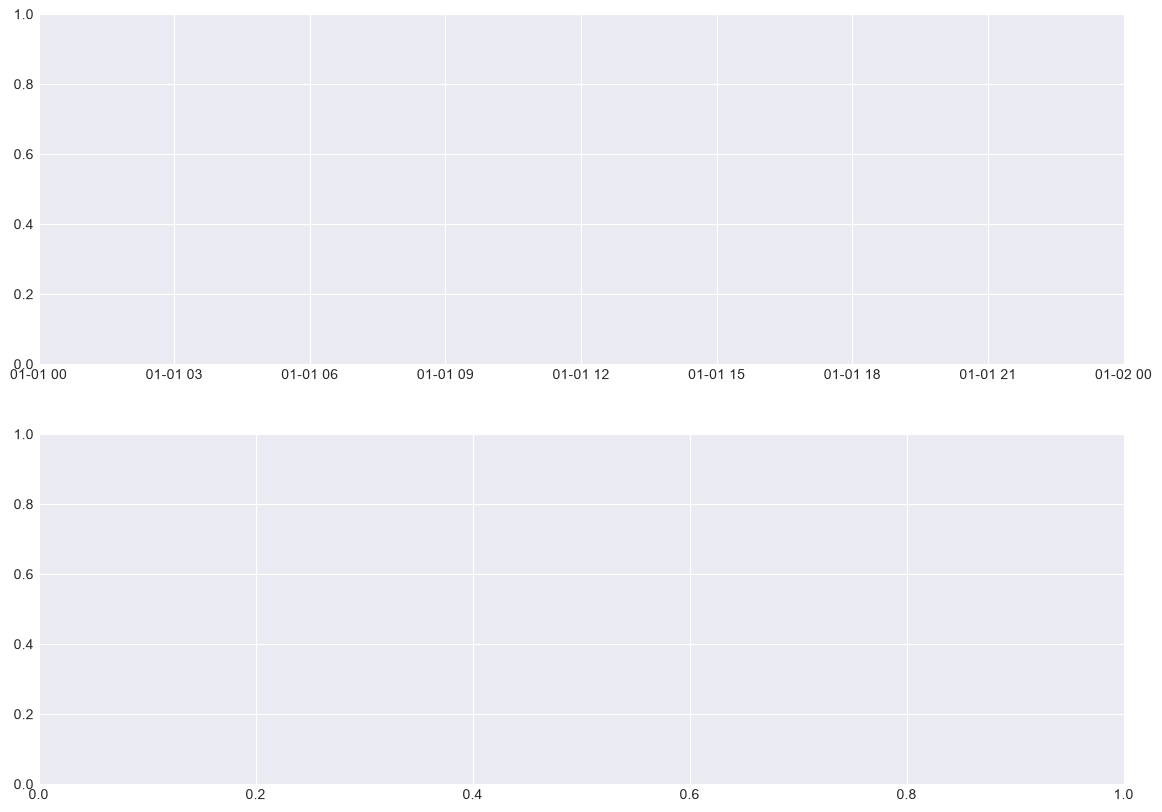

In [4]:
'''
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Сравнение накопленной доходности (Факт vs Прогноз)
axes[0].plot(monthly_dates, cum_predicted * 100, label="Прогнозируемая доходность (ML)", color="orange", linestyle="--", marker="o")
axes[0].plot(cum_actual_daily.index, cum_actual_daily * 100, label="Фактическая доходность", color="green")
axes[0].set_title("Сравнение накопленной доходности портфеля (Факт vs Прогноз)")
axes[0].set_ylabel("Доходность (%)")
axes[0].grid(True)
axes[0].legend()

x = np.arange(len(period_dates))
width = 0.35

axes[1].bar(x - width/2, np.array(predicted_monthly_returns) * 100, width, label="Прогноз на месяц", color="orange", alpha=0.7)
axes[1].bar(x + width/2, np.array(actual_monthly_returns) * 100, width, label="Факт за месяц", color="green", alpha=0.7)
axes[1].set_title("Помесячная доходность: Прогноз vs Факт")
axes[1].set_xticks(x)
axes[1].set_xticklabels(period_dates, rotation=45, ha="right")
axes[1].set_ylabel("Доходность за 20 дней (%)")
axes[1].grid(True, axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()
'''
pred_arr = np.array(predicted_monthly_returns) * 100
act_arr = np.array(actual_monthly_returns) * 100



# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- График 1: Накопленная доходность ---
axes[0].plot(monthly_dates, cum_predicted * 100, label="Прогноз (ML)", color="#ff7f0e", linestyle="--", marker="o", linewidth=2)
axes[0].plot(cum_actual_daily.index, cum_actual_daily * 100, label="Факт (Рынок)", color="#2ca02c", linewidth=2)

axes[0].set_title("Сравнение накопленной доходности портфеля (Калиброванный прогноз vs Факт)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Доходность (%)", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11, loc="upper left")



# --- График 2: Помесячное сравнение ---
x = np.arange(len(period_dates))
width = 0.35

axes[1].bar(x - width/2, pred_arr, width, label="Прогноз на 20д", color="#ff7f0e", alpha=0.75)
axes[1].bar(x + width/2, act_arr, width, label="Факт за 20д", color="#2ca02c", alpha=0.75)

axes[1].set_title("Помесячная доходность за шаги перебалансировки", fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
# Отображение каждой 2-й или 3-й даты, если периодов слишком много
step = 2 if len(period_dates) > 20 else 1
axes[1].set_xticks(x[::step])
axes[1].set_xticklabels(period_dates[::step], rotation=45, ha="right", fontsize=9)

axes[1].set_ylabel("Доходность за 20 дней (%)", fontsize=12)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
import quantstats as qs

# 1. Объединяем ежедневные доходности портфеля в один Pandas Series
portfolio_returns = pd.concat(actual_daily_series)
portfolio_returns.name = "LSTM_Portfolio"

# Удаляем временную зону (если есть) для совпадения индексов
portfolio_returns.index = pd.to_datetime(portfolio_returns.index).tz_localize(None)

# 2. Загружаем бенчмарк (S&P 500 - SPY) за тот же период тестирования
spy = yf.download("SPY", start=portfolio_returns.index[0], end=portfolio_returns.index[-1])["Close"]
spy_returns = spy.pct_change().dropna()
spy_returns.name = "SPY"
spy_returns.index = pd.to_datetime(spy_returns.index).tz_localize(None)

# Синхронизируем даты портфеля и бенчмарка
df_returns = pd.concat([portfolio_returns, spy_returns], axis=1).dropna()
port_ret = df_returns["LSTM_Portfolio"]
bench_ret = df_returns["SPY"]

# 3. Расширенная аналитика в консоли
print("\n=== ОСНОВНЫЕ МЕТРИКИ ПОРТФЕЛЯ (QuantStats) ===")
qs.extend_pandas()

print(f"CAGR (Годовая доходность): {qs.stats.cagr(port_ret) * 100:.2f}%")
print(f"Коэффициент Шарпа:         {qs.stats.sharpe(port_ret):.2f}")
print(f"Коэффициент Сортино:       {qs.stats.sortino(port_ret):.2f}")
print(f"Максимальная просадка:     {qs.stats.max_drawdown(port_ret) * 100:.2f}%")
print(f"Винрейт (Доля прибыльных дней): {qs.stats.win_rate(port_ret) * 100:.2f}%")

# 4. Визуальный сводный отчет (Графики)
qs.plots.snapshot(port_ret, title="LSTM + PyPortfolioOpt Performance", show=True)

# 5. Генерация полного HTML-отчета
qs.reports.html(port_ret, benchmark=bench_ret, output="portfolio_report.html", title="LSTM Portfolio vs S&P 500")
print("\n Полный HTML-отчет сохранен в файл 'portfolio_report.html'")